# **🩺  Breast Cancer Image Classifier Using CNNs  🖼️**

**What this project does:**

* Teaches a computer to look at breast cancer images and decide if a tumor is **benign** ✅ (not harmful) or **malignant** ❌ (cancerous).

**How it uses CNNs 🤖:**

* CNNs (Convolutional Neural Networks) are special types of neural networks that are **really good at understanding images.**

* They can detect patterns like edges, shapes, and textures in the images that help tell if a tumor is safe or dangerous.

**Real-world impact 🌍 :**

* This kind of AI can help doctors **catch cancer earlier** and **make faster diagnoses.**

* It shows how deep learning can be used in **medical imaging** to save lives.

# **Step 1: Install & Import Libraries**

* Install kagglehub to get datasets from Kaggle.

* Import PyTorch (for deep learning), TorchVision (for images), and Matplotlib (to see images).

In [ ]:
!pip install kagglehub -q

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

import random
import matplotlib.pyplot as plt


# **Step 2: Download Dataset**

* Download the Breast Cancer images from Kaggle using kagglehub.

* Set the path to the folder where the images are stored.

* You only need to do this once; after that it will load faster.

In [ ]:
# tool to get datasets from Kaggle

import kagglehub
# Download the Multi Cancer dataset (saved in cache if already downloaded)
path = kagglehub.dataset_download("obulisainaren/multi-cancer")


# Path to the Breast Cancer folder inside the dataset
data_path = f"{path}/Multi Cancer/Multi Cancer/Breast Cancer"



Using Colab cache for faster access to the 'multi-cancer' dataset.


# **Step 3: Image Transforms**

* Make all images the same size (64×64 pixels).

* Convert the images to a format PyTorch can work with (tensors).

* This makes it easier for the computer to process them.

In [ ]:
 # resize all images to 64x64 pixels
 # convert images to PyTorch tensors (values 0–1)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# **Step 4: Load Dataset & Subset**

* Load all images and their labels (benign or malignant).

* Split the data into batches of 16 images so the computer can train efficiently.

* Keep the class names so we can label the pictures later.

In [ ]:
# Load the Breast Cancer dataset from the folder structure.
# ImageFolder automatically assigns labels based on subfolder names (e.g., "benign", "malignant").

dataset = datasets.ImageFolder(data_path, transform=transform)

# Create a DataLoader to load the images in small batches of 8.
# shuffle=True makes sure the data is mixed each epoch (better training).
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)


# Get the list of class names from the dataset (e.g., ['benign', 'malignant'])
class_names = dataset.classes
print("Classes:", class_names)



Classes: ['breast_benign', 'breast_malignant']


# **Step 5: Visualize Sample Images**

* Always check the data before training.

* Show 6 sample images with their labels.

* This helps you see what the model will learn from.

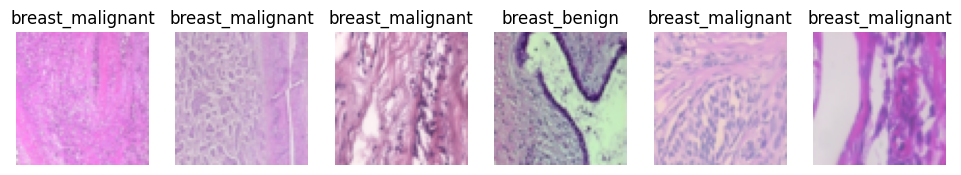

In [ ]:
# Get one batch of images and labels from the DataLoader
images, labels = next(iter(train_loader))

# Create a figure with 1 row and 6 columns of subplots (to show 6 images)
fig, axes = plt.subplots(1, 6, figsize=(12, 4))

# Loop over the first 6 images in the batch
for i in range(6):
    # Images are in [C, H, W] format (channels first), so we permute to [H, W, C] for plotting
    img = images[i].permute(1, 2, 0).numpy()

    # Show the image in the subplot
    axes[i].imshow(img)

    # Set the title of the subplot to the class name (e.g., "benign" or "malignant")
    axes[i].set_title(class_names[labels[i]])

    # Hide axis ticks and numbers for a cleaner display
    axes[i].axis("off")

# Display all 6 images
plt.show()

# **Step 6: Define a Simple CNN**

* CNN = Convolutional Neural Network, good for images.

* Two layers look at patterns in the image (edges, shapes).

* Pooling layers shrink the image to make it easier to process.

* Flatten the image into a list of numbers, then a final layer predicts the class (benign or malignant).

* ReLU is a simple “on/off” switch for each neuron.

In [ ]:
# Define a simple Convolutional Neural Network (CNN)
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # First convolutional layer: input has 3 channels (RGB), output has 16 feature maps
        # Kernel size = 3x3, padding=1 keeps the output size the same
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)

        # Second convolutional layer: input 16 channels, output 32 feature maps
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        # Max pooling layer: reduces height and width by a factor of 2
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layer is not defined yet.
        # We’ll create it dynamically in forward() once we know the input size.
        self.fc = None

    def forward(self, x):
        # Apply first convolution + ReLU activation + pooling
        x = self.pool(torch.relu(self.conv1(x)))

        # Apply second convolution + ReLU activation + pooling
        x = self.pool(torch.relu(self.conv2(x)))

        # Flatten the feature maps into a 1D vector (batch_size, features)
        x = x.view(x.size(0), -1)

        # Define the fully connected layer the first time forward() runs,
        # since we now know how many features the flattened tensor has.
        if self.fc is None:
            self.fc = nn.Linear(x.size(1), 2).to(x.device)  # 2 outputs = benign/malignant

        # Pass data through the fully connected layer
        return self.fc(x)

# Select GPU if available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create an instance of the CNN model and move it to the chosen device
model = CNN().to(device)

print("Using device:", device)


Using device: cuda


# **Step 7: Choose Loss and Optimizer**

* Loss function measures how wrong the model is. Lower is better.

* Optimizer decides how to change the model to make it better.

* We use CrossEntropyLoss (for classification) and Adam (popular optimizer).

In [ ]:
# Define the loss function
# CrossEntropyLoss is used for classification problems.
# It compares the model’s predicted class probabilities with the true class labels.

criterion = nn.CrossEntropyLoss()

# Define the optimizer
# Adam is an adaptive optimizer that adjusts learning rates automatically.
# We pass in all model parameters and set the learning rate to 0.001.
optimizer = optim.Adam(model.parameters(), lr=0.001)


# **Step 8: Train the Model**

* Repeat 3 times (3 epochs) to teach the model.

* For each batch of images:

  - Look at the images and predict labels.
  - Check how wrong the predictions are.
  - Update the model to improve predictions.
  - Count how many predictions were correct.
* Save the loss and accuracy so we can see progress.

In [ ]:
# Lists to store loss and accuracy values after each epoch
train_losses, train_accs = [], []

# Train for 2 epochs (set small for quick demo; increase for real training)
for epoch in range(2):
    # Track accuracy and loss during this epoch
    correct, total, running_loss = 0, 0, 0

    # Loop through all batches from the training DataLoader
    for images, labels in train_loader:
        # Move data to GPU if available
        images, labels = images.to(device), labels.to(device)

        # Reset gradients from the previous step
        optimizer.zero_grad()

        # Forward pass: get predictions from the model
        outputs = model(images)

        # Compute the loss between predictions and true labels
        loss = criterion(outputs, labels)

        # Backward pass: compute gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        # Get predicted class indices (highest score along dimension 1)
        _, preds = torch.max(outputs, 1)

        # Count correct predictions
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Accumulate loss for this batch
        running_loss += loss.item()

    # Compute accuracy for this epoch
    acc = correct / total

    # Save average loss and accuracy for plotting later
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(acc)

    # Print progress

    print(f"Epoch {epoch+1}, Loss={train_losses[-1]:.4f}, Accuracy={acc:.2f}")



Epoch 1, Loss=0.5161, Accuracy=0.75
Epoch 2, Loss=0.3996, Accuracy=0.83


# **Step 9: Testing with a Random Image**

* Pick a random image and its true label from the dataset.

* Show the image with its actual label.

* Add a batch dimension and move it to the same device as the model for prediction.

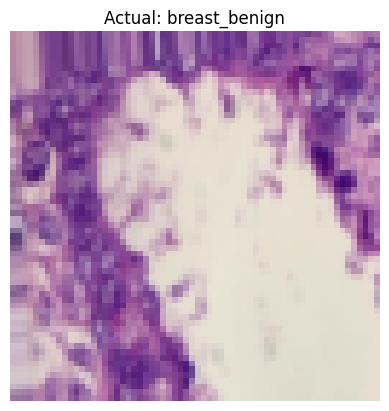

In [ ]:
# Pick a random index from the dataset

idx = random.randint(0, len(dataset)-1)

# Get the image and its label
# img is a tensor of shape [C, H, W], label is the class index (0 or 1)
img, label = dataset[idx]

# ---- Visualize the image ----
# Permute changes tensor shape from [C, H, W] to [H, W, C] for plotting
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title(f"Actual: {class_names[label]}")  # Show the true class name
plt.axis("off")  # Hide axes for cleaner display
plt.show()

# ---- Prepare the image for the model ----
# Add a batch dimension: [C, H, W] → [1, C, H, W]
# Move tensor to GPU (if available)
img_tensor = img.unsqueeze(0).to(device)


# **Step 10: Making a Prediction**

* Tell the model we are just testing, not training.

* Run the image through the model to get a prediction.

* Pick the class with the highest probability.

* Print the predicted label (benign or malignant).

In [ ]:
# Set the model to evaluation mode
# (disables dropout, batch norm updates, etc. for consistent results)

model.eval()

# Turn off gradient calculations (faster + less memory used during inference)

with torch.no_grad():

    # Run the image through the model to get raw predictions (logits)

    output = model(img_tensor)

    # Get the index of the class with the highest score

    predicted_index = torch.argmax(output, 1).item()

# Print the predicted class name (e.g., "benign" or "malignant")

print("Predicted class:", class_names[predicted_index])


Predicted class: breast_benign
